# 01 · Make & explore the WS2 example phantom
### DINO-4DSTEM tutorials

This is the first of four notebooks that walk through the whole DINO-4DSTEM
workflow on a **synthetic WS2 phantom** — a simulated 4D-STEM scan where we
*know the right answer*, so later we can measure how well the model recovers it.

**This notebook:** what 4D-STEM data is → how the phantom is built → make a small
one yourself → examine its **classes/domains**, **virtual image**, and
**diffracting domains** → an interactive ROI → the output data.

## What is 4D-STEM data?

In scanning transmission electron microscopy (STEM) a focused electron probe is
stepped across the sample on an $N_y \times N_x$ grid. At **each** probe
position a pixelated detector records a full 2-D **diffraction pattern**
$(H \times W)$. Stack them and you get a **4-D array**

$$\text{cube}[y, x, :, :] \in \mathbb{R}^{H\times W}, \qquad \text{shape } (N_y, N_x, H, W).$$

Each diffraction pattern encodes the *local crystal structure* under the probe.
A crystal diffracts the beam into discrete **Bragg spots** at reciprocal-lattice
vectors $\mathbf{g}$ (Bragg's law, $2d\sin\theta = \lambda$); **which** spots
appear depends on the crystal's **orientation** — the zone axis facing the beam.
So two grains of the same material but different orientation give **different
diffraction patterns**, and that is the signal we cluster on.

## The WS2 phantom

WS₂ is a layered 2-D material. Our phantom is a **96 × 96 scan** broken into
~64 **Voronoi grains**; each grain is WS₂ in one of **three orientations**
(zone axes $[001], [110], [100]$) and is spun to a **random in-plane angle**.

That in-plane spin is a **nuisance**: it changes the raw pattern but *not* the
class — the "right" label is the 3-D orientation, not the in-plane angle. (A good
model must be invariant to it; that's the whole point of notebook 02.)

Diffraction intensities are scaled to a realistic electron **dose** and can carry
**Poisson (shot) noise** — the finite-count statistics of real detectors.

In [1]:
import os, json, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import ws2_utils as wu; wu.add_src_to_path()

'D:\\DINOSR\\Claude\\PaperRun_claude\\dino_sr_contrastive\\src'

### The recipe

| parameter | value | meaning |
|---|---|---|
| zone axes | [001], [110], [100] | the 3 orientations = the 3 classes |
| scan | 96 × 96 | probe grid |
| `n_voronoi_seeds` | 64 | number of grains (each = 1 orientation + 1 in-plane angle) |
| `engine` | finite | one clean multislice pattern per grain |
| `conv_mrad` | 1.5 | probe convergence → disk size (a few px) |
| `det_max_mrad` | 28 | detector half-angle → the rings fill the frame |
| `dose_e_A2` | 1e4 | electron dose |
| in-plane angle | 0–360° | the within-class **nuisance** |

## 1 · Make one yourself (quick demo)

`wu.make_phantom` drives the **same validated engine** the GUI uses, headless.
The full example takes ~40 min, so we run a tiny/fast version (`WS2_QUICK`:
16 × 16 scan, 2 orientations, small detector) in a few seconds.

> Needs `customtkinter` + `abtem` + `ase`. On a headless box, skip this and use
> the pre-built example in step 2.

In [2]:
demo_dir = os.path.join(wu.repo_root(), 'runs', 'synth', '_tutorial_quick')
cube_q, cmaps_q, meta_q, _ = wu.make_phantom(demo_dir, spec=wu.WS2_QUICK)

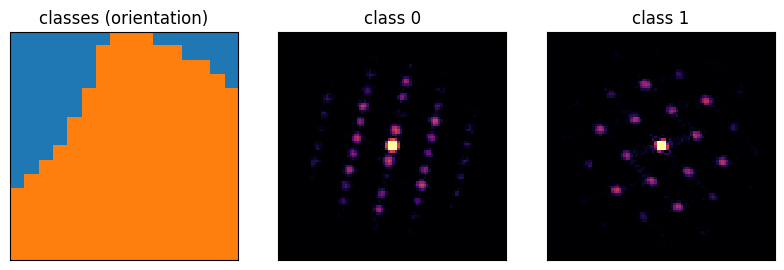

In [3]:
%matplotlib inline
# (making the phantom imported the GUI engine, which switches the matplotlib
#  backend; re-assert inline so the plots below render.)
gt_q = cmaps_q['main']; K = int(gt_q.max()) + 1
fig, ax = plt.subplots(1, 1 + K, figsize=(3 + 2.6*K, 2.7))
ax[0].imshow(gt_q, cmap=wu.class_palette(K)); ax[0].set_title('classes (orientation)')
ax[0].set_xticks([]); ax[0].set_yticks([])
for cls in range(K):
    ys, xs = np.where(gt_q == cls)
    wu.logshow(ax[1+cls], cube_q[ys[0], xs[0]]); ax[1+cls].set_title(f'class {cls}')
plt.tight_layout(); plt.show()

## 2 · The full pre-built example

For the rest of the tutorials we use the **full** 96×96 × 256×256 phantom in
`runs/synth/`. We memory-map the 2.4 GB cube (no RAM blow-up).

In [4]:
ex = wu.find_ws2_example()
cube = np.load(os.path.join(ex, 'phantom.cube.npy'), mmap_mode='r')   # (Ny,Nx,H,W)
gt   = np.load(os.path.join(ex, 'phantom.classmap_main.npy'))         # ground truth
Ny, Nx, H, W = cube.shape

## 3 · The classes & domains

Five ground-truth labellings are stored. `main` (orientation) is the primary
target; `grain_map` shows the Voronoi domains the sample was built from.

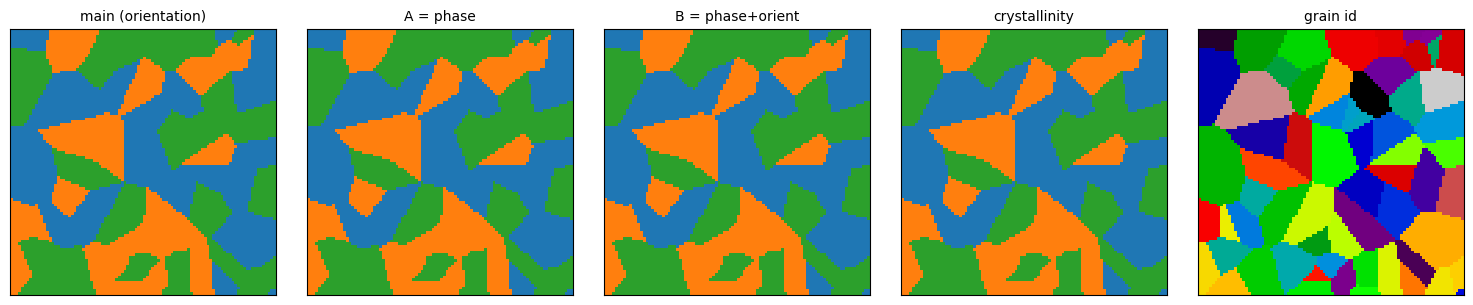

In [5]:
panels = [('main', 'main (orientation)'), ('A', 'A = phase'),
          ('B', 'B = phase+orient'), ('crys', 'crystallinity'),
          ('grain_map', 'grain id')]
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, (nm, t) in zip(ax, panels):
    fn = 'phantom.grain_map.npy' if nm == 'grain_map' else f'phantom.classmap_{nm}.npy'
    m = np.load(os.path.join(ex, fn))
    cmap = 'nipy_spectral' if nm == 'grain_map' else wu.class_palette(int(m.max())+1)
    a.imshow(m, cmap=cmap, interpolation='nearest'); a.set_title(t, fontsize=10)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 4 · Virtual image

A **virtual detector** integrates part of every diffraction pattern into one
real-space pixel — a linear functional of the pattern. **Bright-field** sums the
central disk; **HAADF** sums an outer annulus (sensitive to scattering):

$$\text{BF}(y,x) = \!\!\sum_{r<r_0}\!\! I_{yx}(r,\theta), \qquad
  \text{HAADF}(y,x) = \!\!\sum_{r_1<r<r_2}\!\! I_{yx}(r,\theta).$$

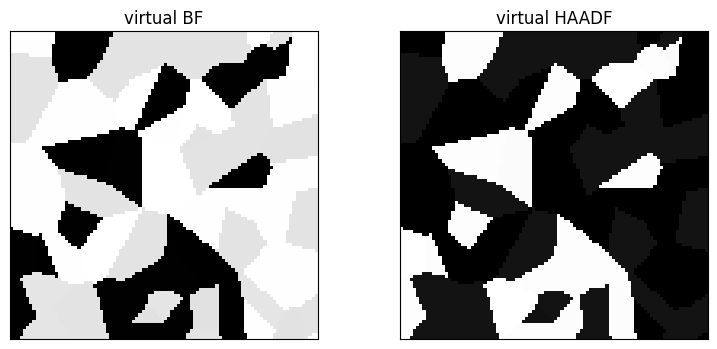

In [6]:
bf, ha = wu.virtual_bf_haadf(cube)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
for a, im, t in zip(ax, [bf, ha], ['virtual BF', 'virtual HAADF']):
    lo, hi = np.percentile(im, [1, 99]); a.imshow(np.clip(im, lo, hi), cmap='gray')
    a.set_title(t); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 5 · The diffracting domains

The **mean diffraction of each class** — averaging over a class (all its in-plane
rotations) turns Bragg spots into rings, and each orientation has a distinct
fingerprint. This is *why* the classes are separable.

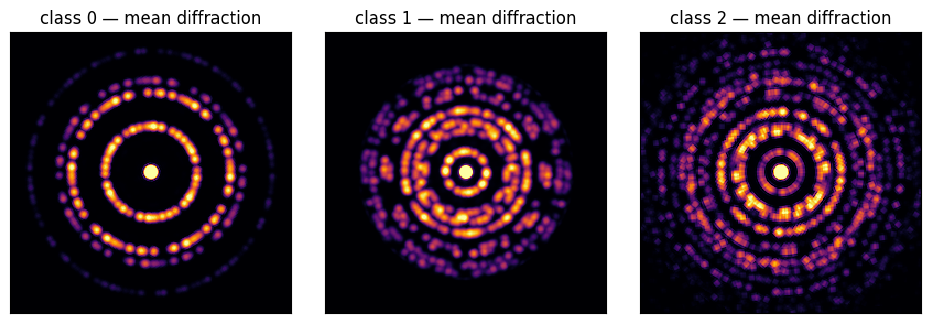

In [7]:
cmd = wu.class_mean_diffraction(cube, gt, max_per_class=300)
fig, ax = plt.subplots(1, len(cmd), figsize=(3.2*len(cmd), 3.2))
for a, (cls, dp) in zip(np.atleast_1d(ax), sorted(cmd.items())):
    wu.logshow(a, dp); a.set_title(f'class {cls} — mean diffraction')
plt.tight_layout(); plt.show()

## 6 · Interactive ROI

Drag a box on the virtual image → the mean diffraction of that ROI updates live.
For the live version, run this in Jupyter:

```python
%matplotlib widget
wu.interactive_roi(cube, bf)
```

(A static snapshot runs below so the notebook executes end-to-end.)

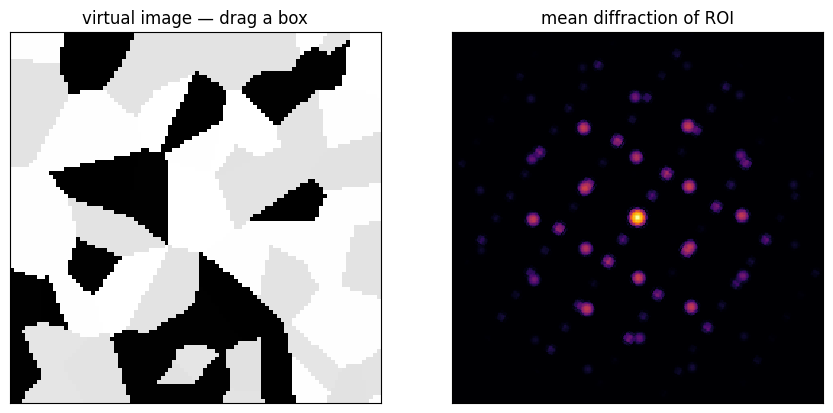

In [8]:
wu.interactive_roi(cube, bf, roi=(10, 10)); plt.show()

## 7 · The output data

Saved next to the cube — this is what notebooks 02–04 load:

| file | what |
|---|---|
| `phantom.cube.npy` | the 4-D cube `(Ny, Nx, H, W)` float32 |
| `phantom.classmap_main.npy` | ground-truth class map (orientation) |
| `phantom.classmap_{A,B,crys,C}.npy` | finer / control labellings |
| `phantom.grain_map.npy` | Voronoi grain ids |
| `phantom.sim_meta.json` | all simulation parameters |

**Next → `02_load_preprocess_train.ipynb`**: load this cube, pre-process it, and
train the self-supervised model.